In [14]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import folium

# Load dataset
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/historical_automobile_sales.csv"
df = pd.read_csv(URL)

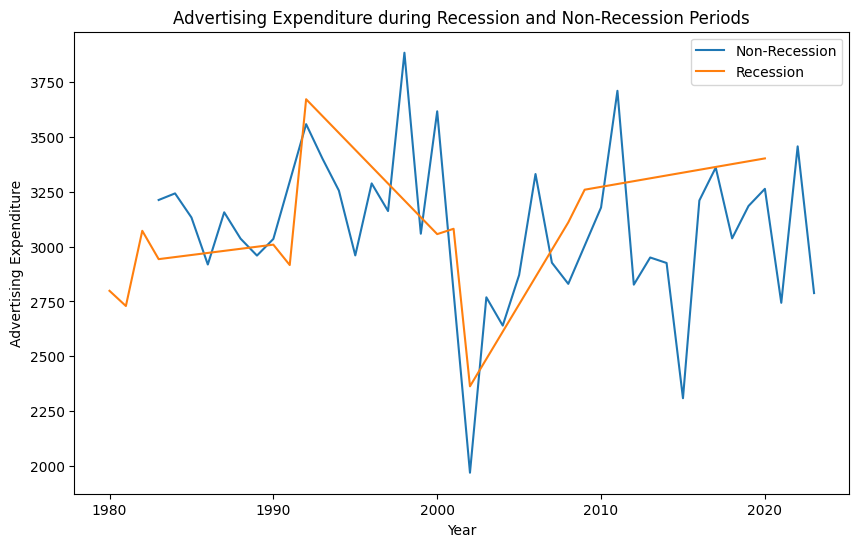

In [15]:
df_rec = df[df['Recession'] == 1]
df_nonrec = df[df['Recession'] == 0]

plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Year', y='Advertising_Expenditure', hue='Recession', errorbar=None)
plt.title('Advertising Expenditure during Recession and Non-Recession Periods')
plt.xlabel('Year')
plt.ylabel('Advertising Expenditure')
plt.legend(['Non-Recession', 'Recession'])
plt.show()

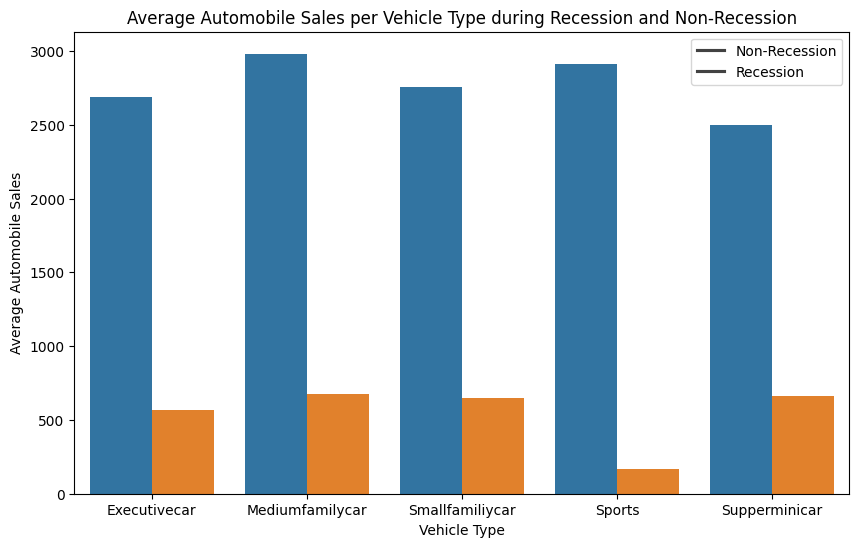

In [17]:
vt_sales = df.groupby(['Vehicle_Type', 'Recession'])['Automobile_Sales'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=vt_sales, x='Vehicle_Type', y='Automobile_Sales', hue='Recession')
plt.title('Average Automobile Sales per Vehicle Type during Recession and Non-Recession')
plt.xlabel('Vehicle Type')
plt.ylabel('Average Automobile Sales')
plt.legend(['Non-Recession', 'Recession'])
plt.show()

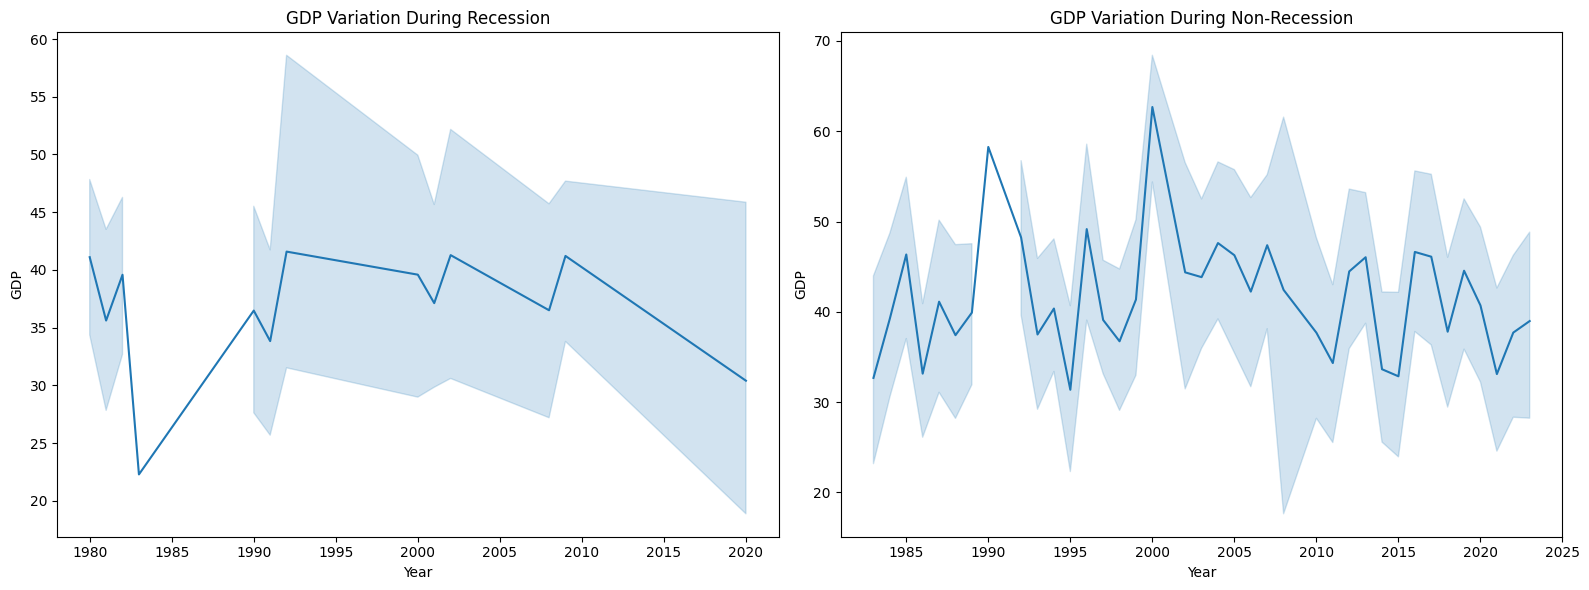

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(data=df[df['Recession'] == 1], x='Year', y='GDP', ax=axes[0])
axes[0].set_title('GDP Variation During Recession')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('GDP')

sns.lineplot(data=df[df['Recession'] == 0], x='Year', y='GDP', ax=axes[1])
axes[1].set_title('GDP Variation During Non-Recession')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('GDP')

plt.tight_layout()
plt.show()

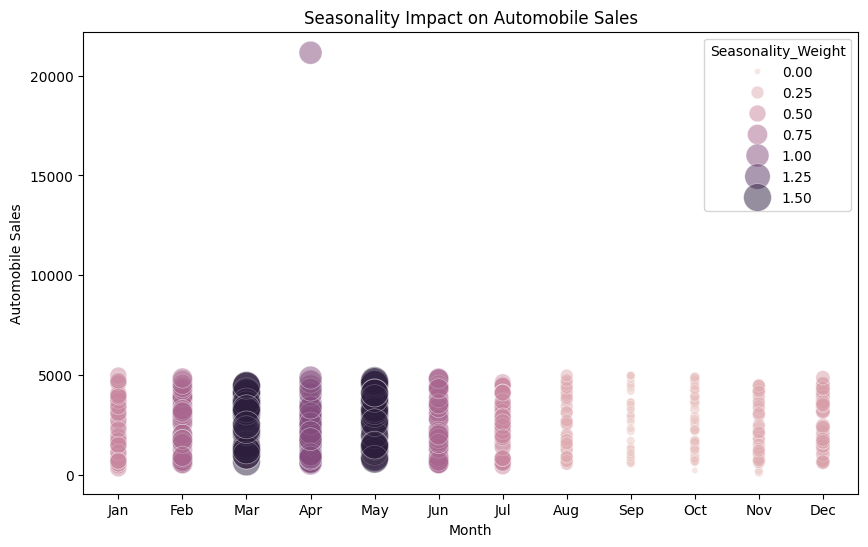

In [19]:
plt.figure(figsize=(10, 6))
# Using 'Month' on the x-axis, scaling bubble size by 'Seasonality_Weight'
sns.scatterplot(data=df, x='Month', y='Automobile_Sales', size='Seasonality_Weight', sizes=(20, 400), hue='Seasonality_Weight', alpha=0.5)
plt.title('Seasonality Impact on Automobile Sales')
plt.xlabel('Month')
plt.ylabel('Automobile Sales')
plt.show()

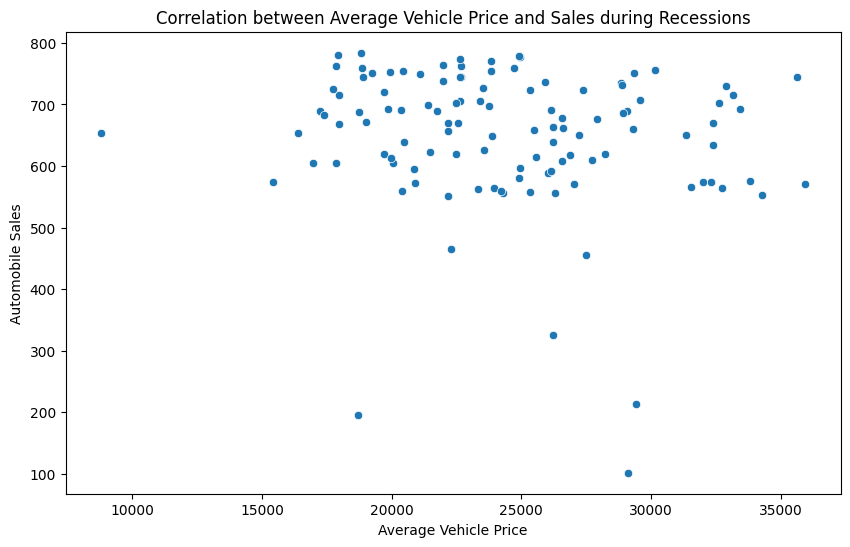

In [20]:
# Filter the dataset for recession periods only
df_rec = df[df['Recession'] == 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_rec, x='Price', y='Automobile_Sales')
plt.title('Correlation between Average Vehicle Price and Sales during Recessions')
plt.xlabel('Average Vehicle Price')
plt.ylabel('Automobile Sales')
plt.show()

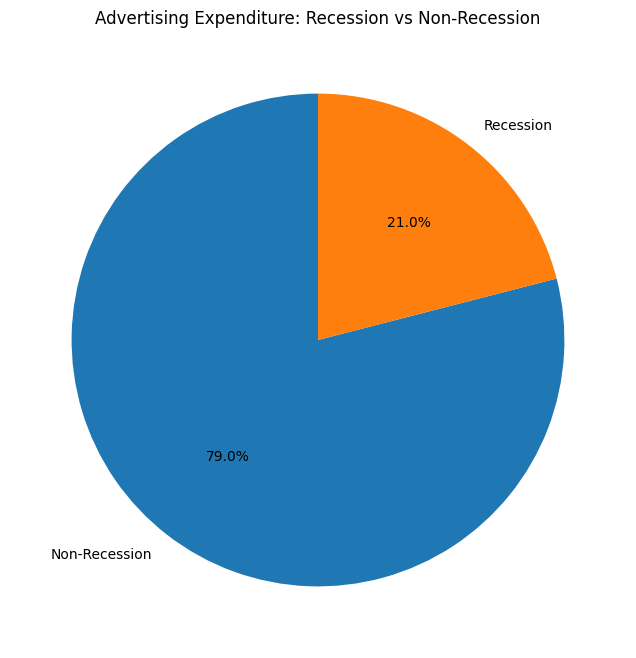

In [21]:
df_pie1 = df.groupby('Recession')['Advertising_Expenditure'].sum()

plt.figure(figsize=(8, 8))
plt.pie(df_pie1, labels=['Non-Recession', 'Recession'], autopct='%1.1f%%', startangle=90)
plt.title('Advertising Expenditure: Recession vs Non-Recession')
plt.show()

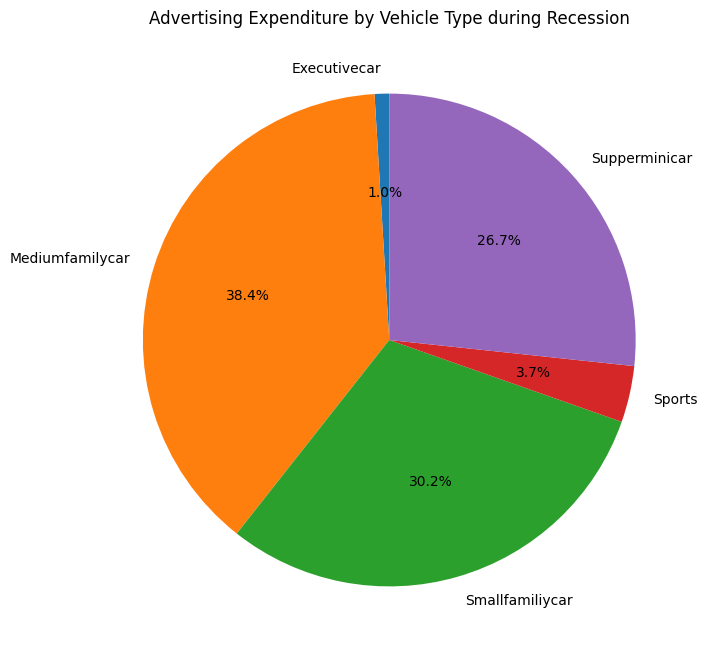

In [22]:
df_pie2 = df_rec.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()

plt.figure(figsize=(8, 8))
plt.pie(df_pie2, labels=df_pie2.index, autopct='%1.1f%%', startangle=90)
plt.title('Advertising Expenditure by Vehicle Type during Recession')
plt.show()

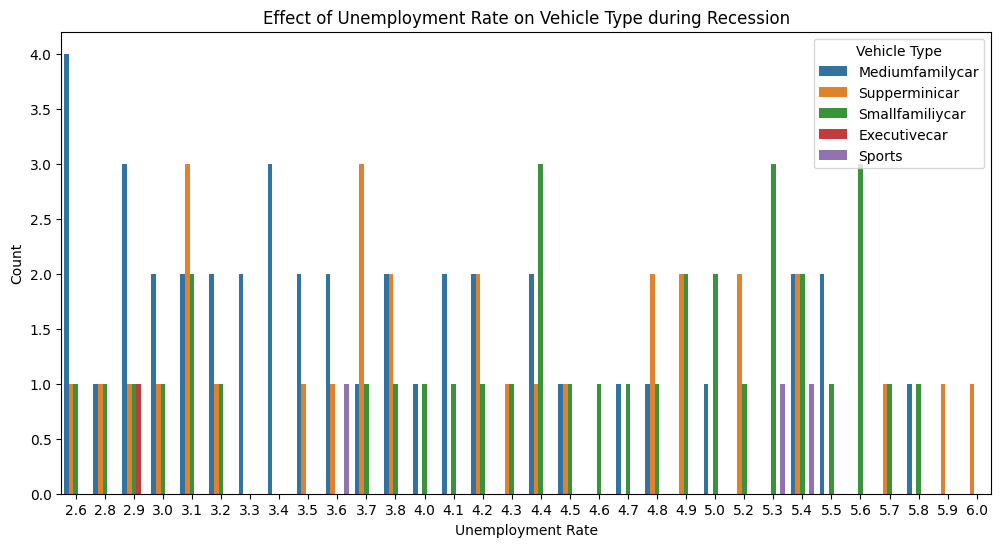

In [23]:
plt.figure(figsize=(12, 6))
# Note: Ensure the column name exactly matches your dataset (usually 'unemployment_rate' or 'Unemployment_Rate')
sns.countplot(data=df_rec, x='unemployment_rate', hue='Vehicle_Type')
plt.title('Effect of Unemployment Rate on Vehicle Type during Recession')
plt.xlabel('Unemployment Rate')
plt.ylabel('Count')
plt.legend(title='Vehicle Type')
plt.show()